In [4]:
# W3D4: SVM & KNN — When to Use What

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [5]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Dataset Shape:", X.shape)

print("\nTarget Classes:")
print(data.target_names)

display(X.head())

Dataset Shape: (569, 30)

Target Classes:
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 455
Testing Samples: 114


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [8]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

print("SVM Accuracy:", round(svm_accuracy, 4))

SVM Accuracy: 0.9825


In [9]:
print("===== SVM Classification Report =====")

print(
    classification_report(
        y_test,
        svm_pred,
        target_names=data.target_names
    )
)

print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

===== SVM Classification Report =====
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

SVM Confusion Matrix:
[[41  1]
 [ 1 71]]


In [10]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_pred = knn_model.predict(
    X_test_scaled
)

knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

print("KNN Accuracy:", round(knn_accuracy, 4))

KNN Accuracy: 0.9561


In [11]:
print("===== KNN Classification Report =====")

print(
    classification_report(
        y_test,
        knn_pred,
        target_names=data.target_names
    )
)

print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

===== KNN Classification Report =====
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

KNN Confusion Matrix:
[[39  3]
 [ 2 70]]


In [12]:
results = pd.DataFrame({
    "Model": [
        "SVM",
        "KNN"
    ],
    "Accuracy": [
        svm_accuracy,
        knn_accuracy
    ]
})

print("===== Model Comparison =====")

display(results)

===== Model Comparison =====


,Model,Accuracy
0,SVM,0.982456
1,KNN,0.956140


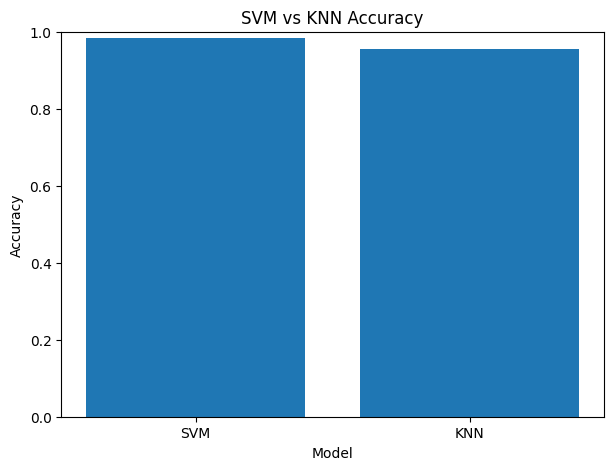

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("SVM vs KNN Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

In [14]:
k_values = [3, 5, 7, 9, 11]
knn_scores = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    prediction = model.predict(
        X_test_scaled
    )

    score = accuracy_score(
        y_test,
        prediction
    )

    knn_scores.append(score)

knn_results = pd.DataFrame({
    "K": k_values,
    "Accuracy": knn_scores
})

display(knn_results)

,K,Accuracy
0,3,0.982456
1,5,0.956140
2,7,0.973684
3,9,0.973684
4,11,0.973684


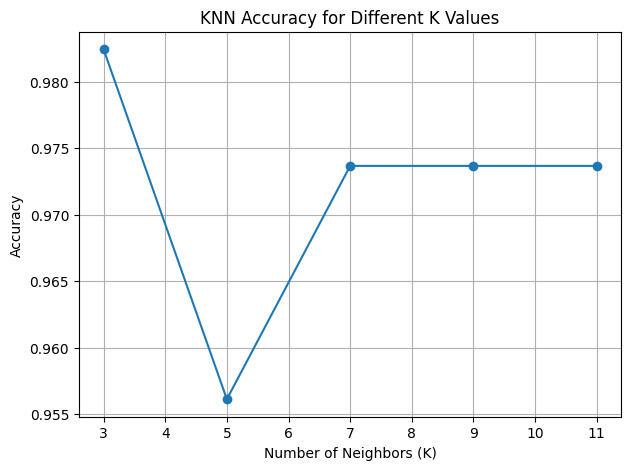

In [15]:
plt.figure(figsize=(7, 5))

plt.plot(
    k_values,
    knn_scores,
    marker="o"
)

plt.title("KNN Accuracy for Different K Values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [16]:
results.to_csv(
    "W3D4_SVM_KNN_Results.csv",
    index=False
)

knn_results.to_csv(
    "W3D4_KNN_K_Comparison.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.
